# E-Commerce Product Recommendation & Customer Segmentation

**Domain:** E-Commerce and Retail Analytics

**Problem Statement:**
This project examines transaction data from an online retail business to:
1. Segment customers based on RFM (Recency, Frequency, Monetary) analysis using KMeans clustering
2. Build a product recommendation system using item-based collaborative filtering

**Problem Type:**
- Unsupervised ML - Clustering
- Collaborative Filtering - Recommendation System


## Step 1: Dataset Collection and Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("Libraries imported successfully")


Libraries imported successfully


In [3]:
# Load dataset
df = pd.read_csv('online_retail.csv', encoding='utf-8-sig')
print(f"Shape: {df.shape}")
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Statistical summary
df.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# Dataset description
dataset_desc = pd.DataFrame({
    'Column': df.columns,
    'Description': [
        'Transaction number', 'Unique product/item code', 'Name of the product',
        'Number of products purchased', 'Date and time of transaction (2022-2023)',
        'Price per product', 'Unique identifier for each customer',
        'Country where customer is based'
    ],
    'Dtype': df.dtypes.values.astype(str),
    'Non-Null': df.notnull().sum().values,
    'Null': df.isnull().sum().values,
    'Unique': df.nunique().values
})
dataset_desc


,Column,Description,Dtype,Non-Null,Null,Unique
0,InvoiceNo,Transaction number,object,541909,0,25900
1,StockCode,Unique product/item code,object,541909,0,4070
2,Description,Name of the product,object,540455,1454,4223
3,Quantity,Number of products purchased,int64,541909,0,722
4,InvoiceDate,Date and time of transaction (2022-2023),object,541909,0,23260
5,UnitPrice,Price per product,float64,541909,0,1630
6,CustomerID,Unique identifier for each customer,float64,406829,135080,4372
7,Country,Country where customer is based,object,541909,0,38


In [7]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal rows with missing values: {df.isnull().any(axis=1).sum()}")


Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Total rows with missing values: 135080


In [8]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 5268


In [9]:
# Unusual records
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled invoices: {len(cancelled)}")
print(f"Negative/zero Quantity: {(df['Quantity'] <= 0).sum()}")
print(f"Negative/zero UnitPrice: {(df['UnitPrice'] <= 0).sum()}")


Cancelled invoices: 9288
Negative/zero Quantity: 10624
Negative/zero UnitPrice: 2517


## Step 2: Data Preprocessing
- Remove rows with missing CustomerID
- Exclude cancelled invoices (InvoiceNo starting with 'C')
- Remove negative or zero quantities and prices
- Remove duplicates


In [ ]:
print(f"Original shape: {df.shape}")

# Remove missing CustomerID
df = df[df['CustomerID'].notna()]
print(f"After removing missing CustomerID: {df.shape}")

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('c')]
print(f"After removing cancelled invoices: {df.shape}")

# Remove negative/zero quantity and price
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f"After removing non-positive Qty/Price: {df.shape}")

# Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

# Convert types and create TotalPrice
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"\nFinal shape: {df.shape}")
print(f"Customers: {df['CustomerID'].nunique()}, Products: {df['Description'].nunique()}, Countries: {df['Country'].nunique()}")


Original shape: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing cancelled invoices: (397924, 8)
After removing non-positive Qty/Price: (397884, 8)
After removing duplicates: (392692, 8)

Final shape: (392692, 9)
Customers: 4338, Products: 3877, Countries: 37


In [11]:
# Verify cleaned data
print("Missing values remaining:")
print(df.isnull().sum())
df.head()


Missing values remaining:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Step 3: Exploratory Data Analysis (EDA)

Top 10 Countries by Transactions:
Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64


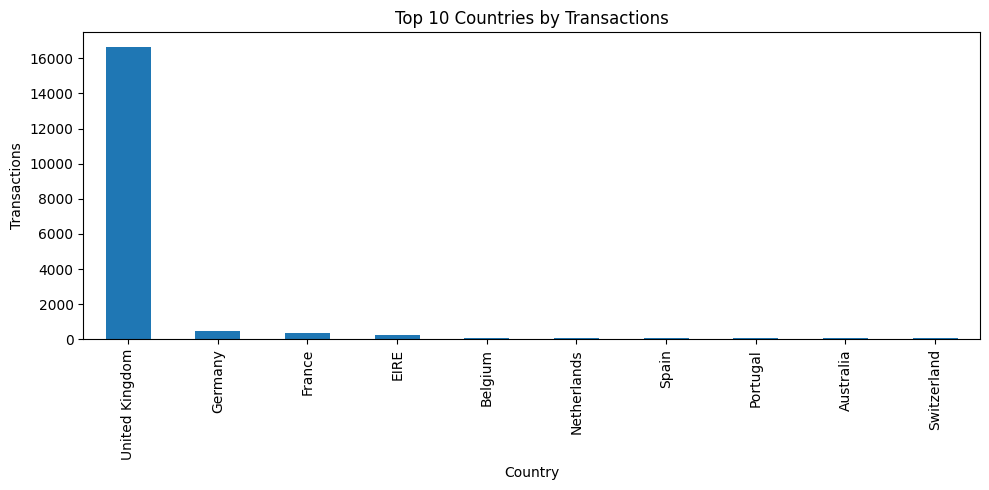

In [12]:
# Transaction volume by country
country_txn = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print("Top 10 Countries by Transactions:")
print(country_txn)

country_txn.plot(kind='bar', figsize=(10, 5), title='Top 10 Countries by Transactions')
plt.ylabel('Transactions')
plt.tight_layout()
plt.show()


Top 10 Products by Quantity Sold:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


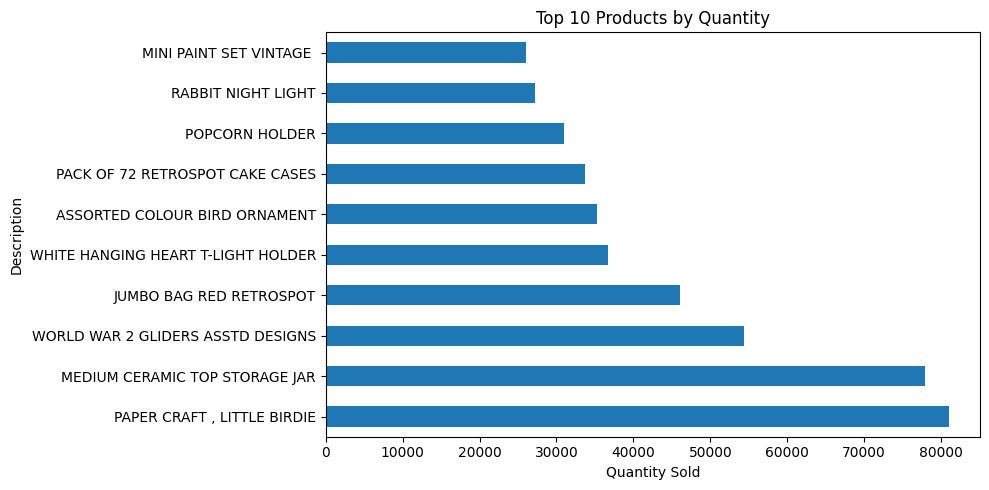

In [13]:
# Top selling products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Quantity Sold:")
print(top_products)

top_products.plot(kind='barh', figsize=(10, 5), title='Top 10 Products by Quantity')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()


           Transactions      Revenue
YearMonth                           
2022-12            1400   570422.730
2023-01             987   568101.310
2023-02             997   446084.920
2023-03            1321   594081.760
2023-04            1149   468374.331
2023-05            1555   677355.150
2023-06            1393   660046.050
2023-07            1331   598962.901
2023-08            1280   644051.040
2023-09            1755   950690.202
2023-10            1929  1035642.450
2023-11            2657  1156205.610
2023-12             778   517190.440


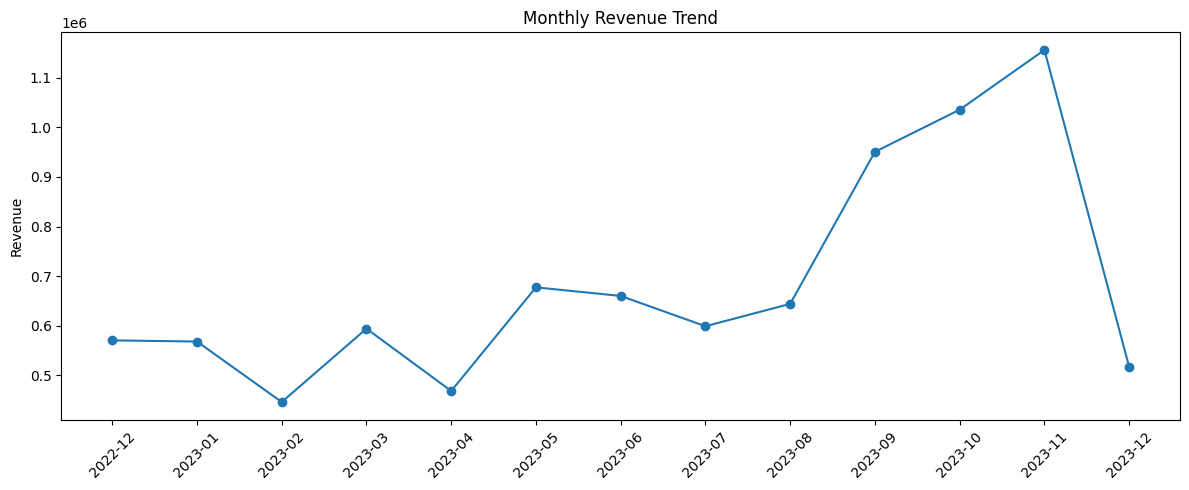

In [15]:
# Purchase trends over time (monthly)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('YearMonth').agg(
    Transactions=('InvoiceNo', 'nunique'),
    Revenue=('TotalPrice', 'sum')
)
print(monthly)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index.astype(str), monthly['Revenue'], marker='o', label='Revenue')
ax1.set_title('Monthly Revenue Trend')
ax1.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


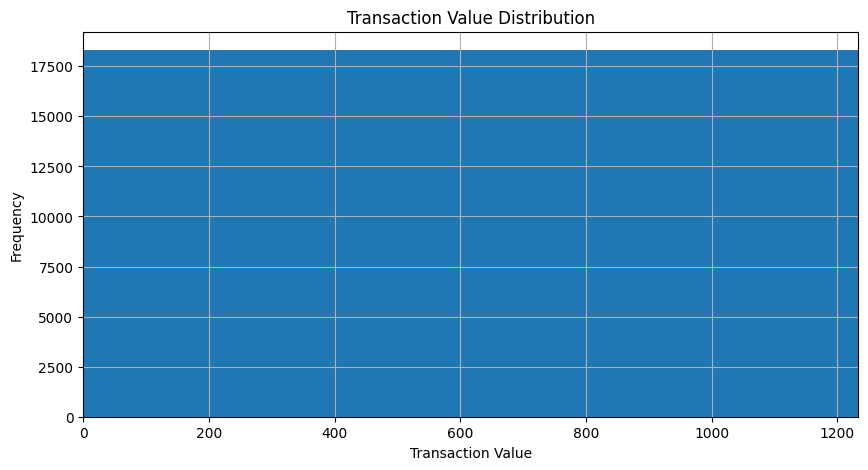

Transaction value stats:
count     18532.00000
mean        479.56016
std        1678.08258
min           0.38000
25%         157.34000
50%         302.57500
75%         469.57000
max      168469.60000
Name: TotalPrice, dtype: float64


In [16]:
# Monetary distribution per transaction
transaction_totals = df.groupby('InvoiceNo')['TotalPrice'].sum()
transaction_totals.hist(bins=50, figsize=(10, 5))
plt.title('Transaction Value Distribution')
plt.xlabel('Transaction Value')
plt.ylabel('Frequency')
plt.xlim(0, transaction_totals.quantile(0.95))
plt.show()

print(f"Transaction value stats:")
print(transaction_totals.describe())


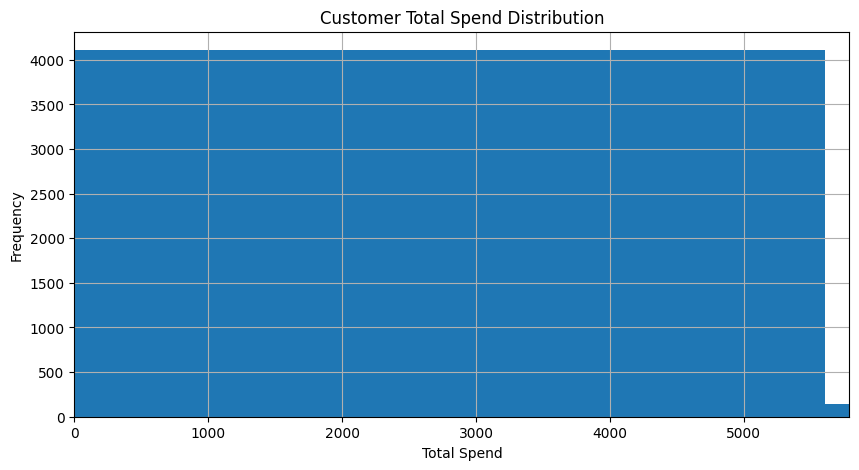

Customer spend stats:
count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalPrice, dtype: float64


In [17]:
# Monetary distribution per customer
customer_totals = df.groupby('CustomerID')['TotalPrice'].sum()
customer_totals.hist(bins=50, figsize=(10, 5))
plt.title('Customer Total Spend Distribution')
plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.xlim(0, customer_totals.quantile(0.95))
plt.show()

print(f"Customer spend stats:")
print(customer_totals.describe())


## Step 4: Clustering Methodology - RFM Analysis ((Recency, Frequency, Monetary))

### 4.1 Feature Engineering - RFM Calculation ['High-Value', 'Regular', 'Occasional', 'At-Risk']

In [18]:
# Calculate RFM
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"RFM table: {len(rfm)} customers")
rfm.describe()


Reference Date: 2023-12-10 12:50:00
RFM table: 4338 customers


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [19]:
rfm.head(10)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


### 4.2 RFM Distributions

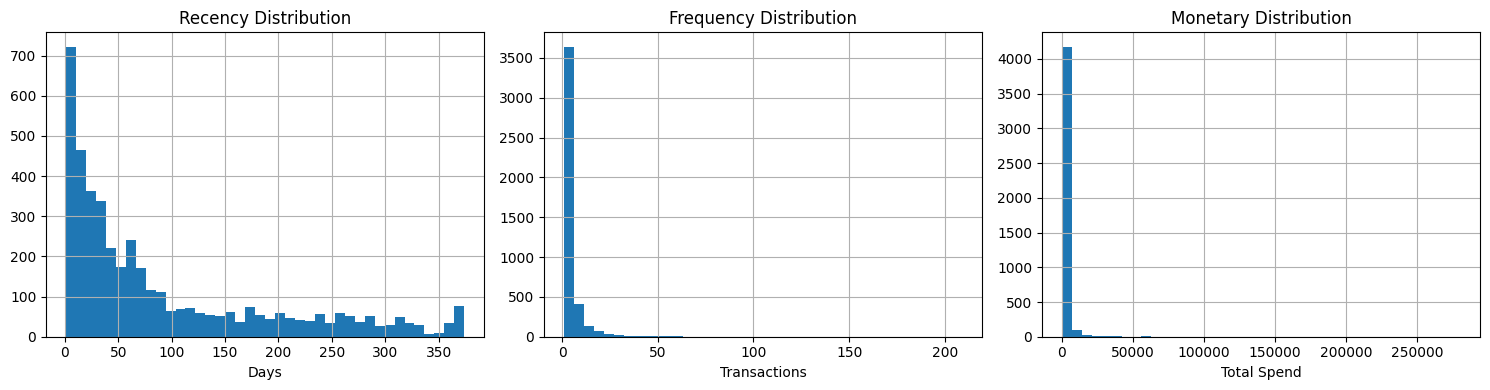

In [20]:
# RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].hist(bins=40, ax=axes[0])
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days')

rfm['Frequency'].hist(bins=40, ax=axes[1])
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Transactions')

rfm['Monetary'].hist(bins=40, ax=axes[2])
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend')

plt.tight_layout()
plt.show()


RFM Correlation:
            Recency  Frequency  Monetary
Recency    1.000000  -0.260578 -0.121831
Frequency -0.260578   1.000000  0.552780
Monetary  -0.121831   0.552780  1.000000


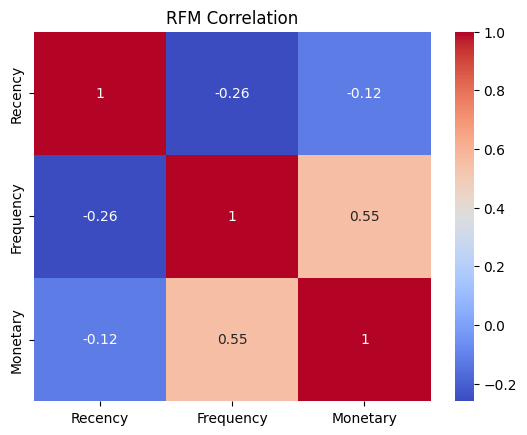

In [21]:
# RFM Correlation
print("RFM Correlation:")
print(rfm[['Recency', 'Frequency', 'Monetary']].corr())

sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation')
plt.show()


### 4.3 Standardize RFM Values

In [22]:
# Standardize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print("RFM values standardized")

pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary']).describe()


RFM values standardized


,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,2.293130e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.276151e-01
25%,-7.453445e-01,-4.250965e-01,-1.939190e-01
50%,-4.153533e-01,-2.951776e-01,-1.536162e-01
75%,4.946227e-01,9.457903e-02,-4.319704e-02
max,2.814561e+00,2.659803e+01,3.096074e+01


### 4.4 Elbow Method & Silhouette Score

K=2: Inertia=9014.57, Silhouette=0.8958
K=3: Inertia=5441.32, Silhouette=0.5942
K=4: Inertia=4096.30, Silhouette=0.6162
K=5: Inertia=3119.79, Silhouette=0.6165
K=6: Inertia=2473.79, Silhouette=0.5983
K=7: Inertia=2023.59, Silhouette=0.5165
K=8: Inertia=1717.01, Silhouette=0.4859
K=9: Inertia=1468.79, Silhouette=0.4784
K=10: Inertia=1281.05, Silhouette=0.4792


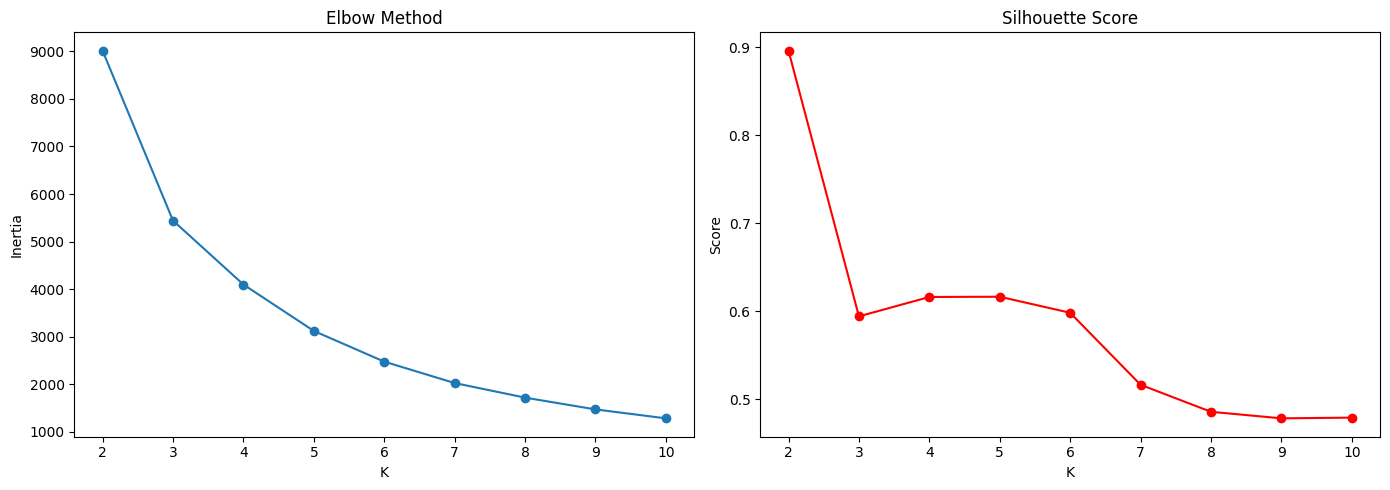


Best K by silhouette: 2


In [23]:
# Elbow method and silhouette score
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'o-', color='red')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest K by silhouette: {best_k}")


### 4.5 Run KMeans Clustering (K=4)

In [24]:
# KMeans with K=4 (for 4 business segments)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)
print(f"Clustering done with K={optimal_k}")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print(f"\nCluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())


Clustering done with K=4
Silhouette Score: 0.6162

Cluster distribution:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


### 4.6 Interpret & Label Clusters

In [25]:
# Cluster summary
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_summary['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
print("Cluster Averages:")
print(cluster_summary)


Cluster Averages:
         Recency  Frequency   Monetary  Count
Cluster                                      
0          43.70       3.68    1353.63   3054
1         248.08       1.55     478.85   1067
2           7.38      82.54  127187.96     13
3          15.50      22.33   12690.50    204


In [26]:
# Label clusters by ranking on monetary
sorted_clusters = cluster_summary.sort_values('Monetary', ascending=False).index.tolist()
print(sorted_clusters)
labels = ['High-Value', 'Regular', 'Occasional', 'At-Risk']
cluster_labels_map = {sorted_clusters[i]: labels[i] for i in range(optimal_k)}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels_map)

print("Cluster -> Segment Mapping:")
for c, l in sorted(cluster_labels_map.items()):
    count = (rfm['Cluster'] == c).sum()
    print(f"  Cluster {c} -> {l} ({count} customers)")

print("\nSegment Meanings:")
print("  High-Value  : Recent, frequent, big spenders")
print("  Regular     : Steady purchasers, not premium")
print("  Occasional  : Rare, occasional purchases")
print("  At-Risk     : Haven't purchased in a long time")


[2, 3, 0, 1]
Cluster -> Segment Mapping:
  Cluster 0 -> Occasional (3054 customers)
  Cluster 1 -> At-Risk (1067 customers)
  Cluster 2 -> High-Value (13 customers)
  Cluster 3 -> Regular (204 customers)

Segment Meanings:
  High-Value  : Recent, frequent, big spenders
  Regular     : Steady purchasers, not premium
  Occasional  : Rare, occasional purchases
  At-Risk     : Haven't purchased in a long time


### 4.7 Cluster Profiles Visualization

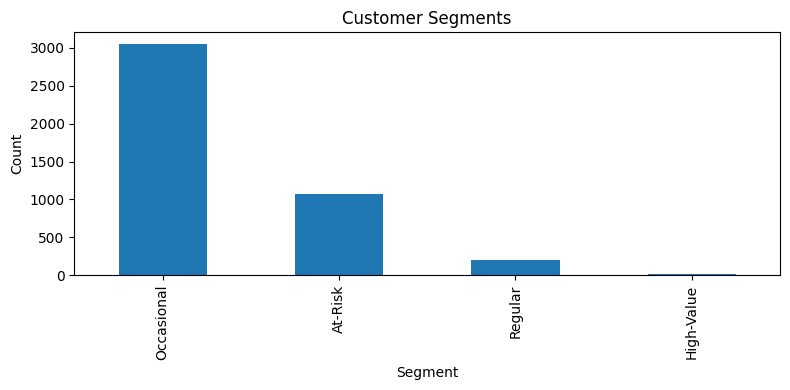

In [27]:
# Segment distribution
rfm['Segment'].value_counts().plot(kind='bar', figsize=(8, 4), title='Customer Segments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Average RFM by Segment:
            Recency  Frequency   Monetary
Segment                                  
At-Risk      248.08       1.55     478.85
High-Value     7.38      82.54  127187.96
Occasional    43.70       3.68    1353.63
Regular       15.50      22.33   12690.50


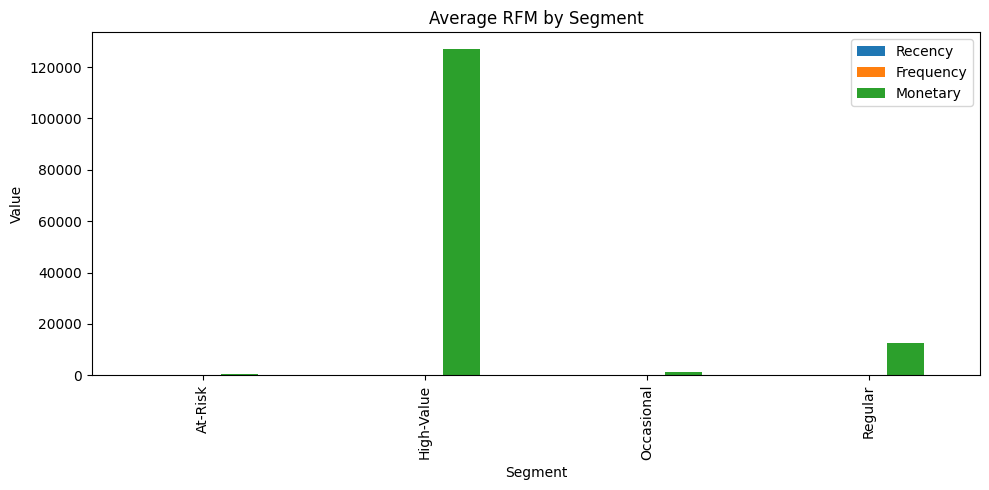

In [28]:
# Average RFM by segment
seg_avg = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
print("Average RFM by Segment:")
print(seg_avg.round(2))

seg_avg.plot(kind='bar', figsize=(10, 5), title='Average RFM by Segment')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


### 4.8 Cluster Scatter Plots

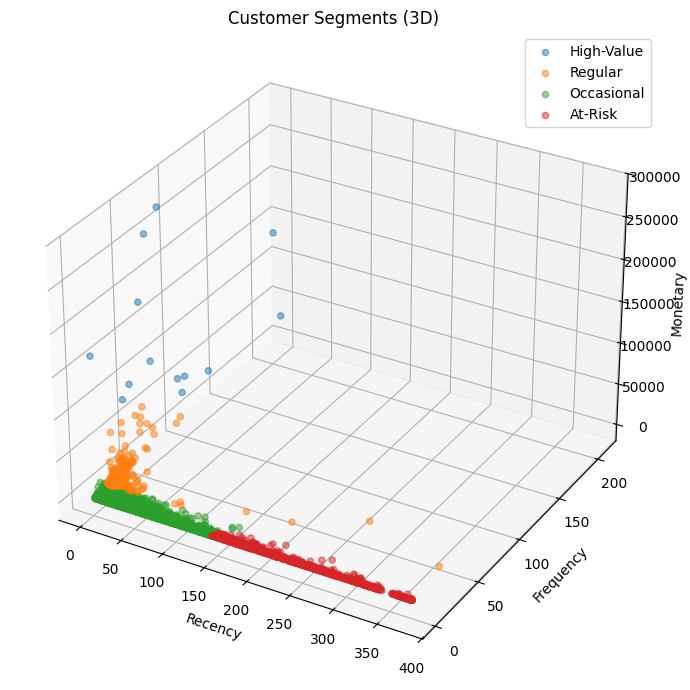

In [29]:
# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for seg in ['High-Value', 'Regular', 'Occasional', 'At-Risk']:
    mask = rfm['Segment'] == seg
    if mask.any():
        ax.scatter(rfm.loc[mask, 'Recency'], rfm.loc[mask, 'Frequency'],
                   rfm.loc[mask, 'Monetary'], label=seg, alpha=0.5, s=20)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Segments (3D)')
ax.legend()
plt.tight_layout()
plt.show()


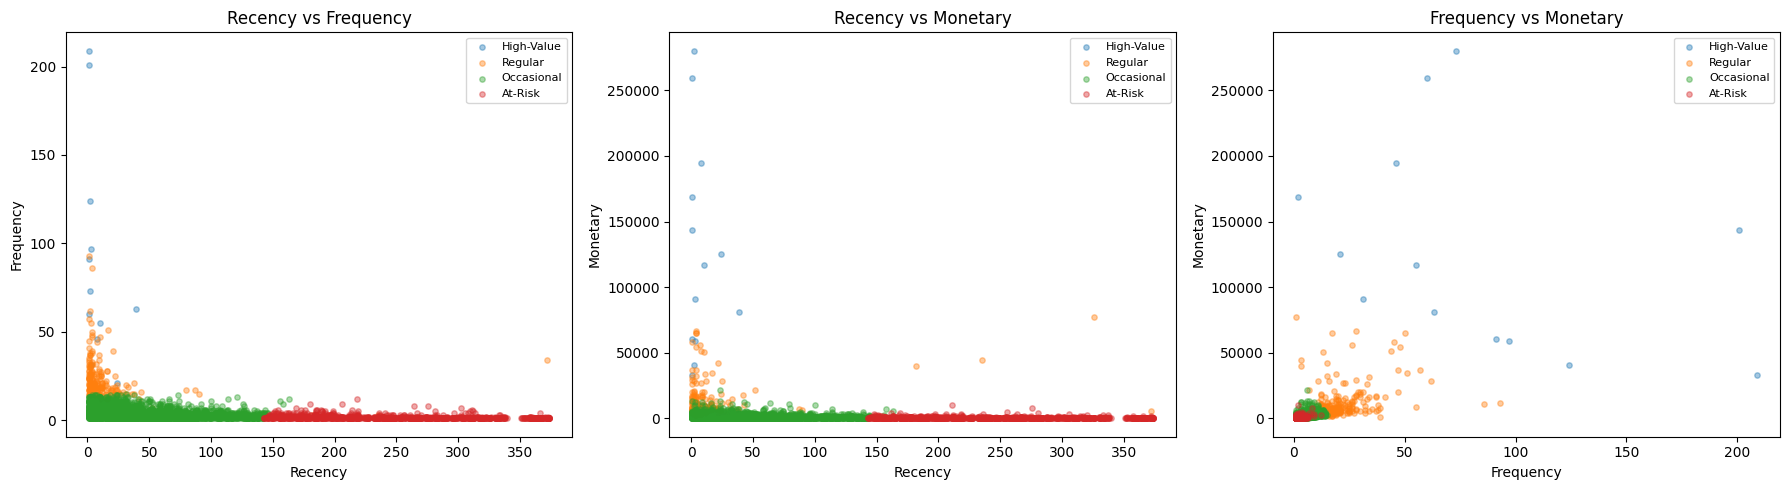

In [30]:
# 2D scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]

for idx, (x, y) in enumerate(pairs):
    for seg in ['High-Value', 'Regular', 'Occasional', 'At-Risk']:
        mask = rfm['Segment'] == seg
        if mask.any():
            axes[idx].scatter(rfm.loc[mask, x], rfm.loc[mask, y], label=seg, alpha=0.4, s=15)
    axes[idx].set_xlabel(x)
    axes[idx].set_ylabel(y)
    axes[idx].set_title(f'{x} vs {y}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 4.9 Save the Model

In [ ]:
# Save model, scaler, and labels
pickle.dump(kmeans_final, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(cluster_labels_map, open('cluster_labels.pkl', 'wb'))

print("Saved: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl")


Saved: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl


## Step 5: Product Recommendation System - Item-based Collaborative Filtering

In [32]:
# Build customer-product purchase matrix
purchase_matrix = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack(fill_value=0)
print(f"Purchase Matrix: {purchase_matrix.shape[0]} customers x {purchase_matrix.shape[1]} products")
print(f"Sparsity: {(purchase_matrix == 0).sum().sum() / (purchase_matrix.shape[0] * purchase_matrix.shape[1]) * 100:.2f}%")



Purchase Matrix: 4338 customers x 3877 products
Sparsity: 98.40%


In [33]:
# Compute cosine similarity between products
item_matrix = purchase_matrix.T
item_similarity = cosine_similarity(item_matrix)
item_similarity_df = pd.DataFrame(item_similarity, index=item_matrix.index, columns=item_matrix.index)
print(f"Similarity Matrix: {item_similarity_df.shape}")

print(item_similarity_df['KNITTED UNION FLAG HOT WATER BOTTLE'].drop('KNITTED UNION FLAG HOT WATER BOTTLE').sort_values(ascending=False))

Similarity Matrix: (3877, 3877)
Description
WOODEN SKITTLES GARDEN SET         0.553841
KINGS CHOICE GIANT TUBE MATCHES    0.505119
OFFICE MUG WARMER BLACK+SILVER     0.504578
RETROSPOT GIANT TUBE MATCHES       0.502279
TRAY, BREAKFAST IN BED             0.493944
                                     ...   
PEARL & SHELL 42"NECKL. GREEN      0.000000
PEARL & SHELL 42"NECKL. IVORY      0.000000
WOVEN BUBBLE GUM CUSHION COVER     0.000000
WRAP  PINK FLOCK                   0.000000
PEACH KNITTED HEN                  0.000000
Name: KNITTED UNION FLAG HOT WATER BOTTLE, Length: 3876, dtype: float64


In [34]:
# Recommendation function
def get_recommendations(product_name, similarity_df, top_n=5):
    """Return top N similar products for a given product name."""
    if product_name not in similarity_df.index:
        # Try partial match
        matches = [p for p in similarity_df.index if product_name.upper() in p.upper()]
        if not matches:
            return f"Product '{product_name}' not found."
        product_name = matches[0]
        print(f"Matched to: '{product_name}'")
    
    scores = similarity_df[product_name].drop(product_name).sort_values(ascending=False)
    top = scores.head(top_n)
    result = pd.DataFrame({'Product': top.index, 'Similarity': top.values})
    result.index = range(1, len(result) + 1)
    return result

# Test
sample = df['Description'].value_counts().index[0]
print(f"Recommendations for: '{sample}'")
print(get_recommendations(sample, item_similarity_df))


Recommendations for: 'WHITE HANGING HEART T-LIGHT HOLDER'
                            Product  Similarity
1       GIN + TONIC DIET METAL SIGN    0.750192
2  RED HANGING HEART T-LIGHT HOLDER    0.658714
3               WASHROOM METAL SIGN    0.643520
4            LAUNDRY 15C METAL SIGN    0.642200
5         GREEN VINTAGE SPOT BEAKER    0.631463


In [35]:
# Test with more products
test_products = df['Description'].value_counts().index[:3]
for p in test_products:
    print(f"\nProduct: '{p}'")
    print(get_recommendations(p, item_similarity_df))



Product: 'WHITE HANGING HEART T-LIGHT HOLDER'
                            Product  Similarity
1       GIN + TONIC DIET METAL SIGN    0.750192
2  RED HANGING HEART T-LIGHT HOLDER    0.658714
3               WASHROOM METAL SIGN    0.643520
4            LAUNDRY 15C METAL SIGN    0.642200
5         GREEN VINTAGE SPOT BEAKER    0.631463

Product: 'REGENCY CAKESTAND 3 TIER'
                               Product  Similarity
1         MINI PLAYING CARDS FUN FAIR     0.701600
2  BOX OF 6 CHRISTMAS CAKE DECORATIONS    0.699300
3       BLACK LOVE BIRD T-LIGHT HOLDER    0.691069
4      MIRROR LOVE BIRD T-LIGHT HOLDER    0.690944
5                   BLUE POLKADOT WRAP    0.684648

Product: 'JUMBO BAG RED RETROSPOT'
                          Product  Similarity
1            JUMBO BAG STRAWBERRY    0.900622
2         JUMBO BAG PINK POLKADOT    0.895499
3                  JUMBO BAG OWLS    0.801018
4  JUMBO BAG PINK VINTAGE PAISLEY    0.788298
5                JUMBO BAG APPLES    0.761323


### Product Similarity Heatmap

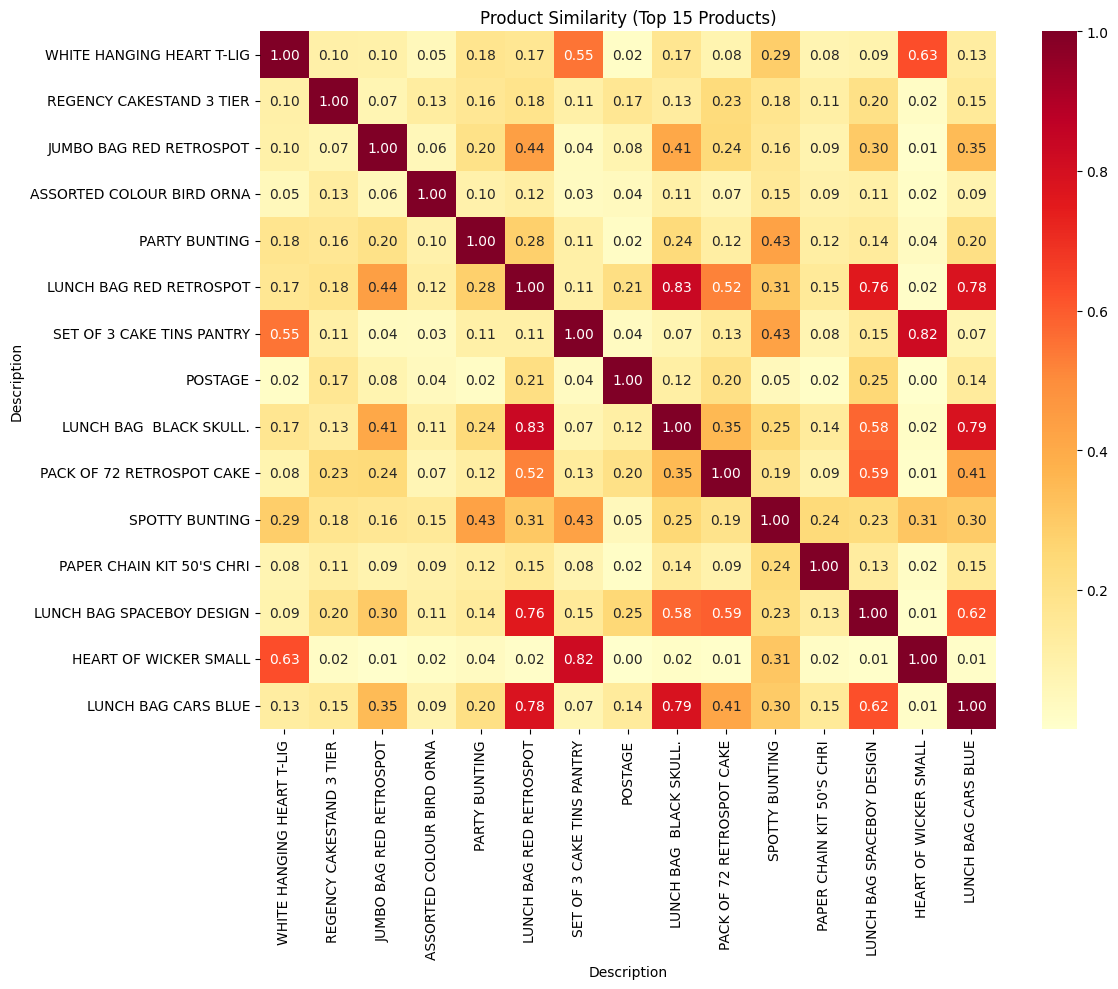

In [36]:
# Similarity heatmap for top 15 products
top15 = df['Description'].value_counts().index[:15]
sim_subset = item_similarity_df.loc[top15, top15]

plt.figure(figsize=(12, 10))
sns.heatmap(sim_subset, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[p[:25] for p in top15],
            yticklabels=[p[:25] for p in top15])
plt.title('Product Similarity (Top 15 Products)')
plt.tight_layout()
plt.show()


In [ ]:
# Save recommendation artifacts
item_similarity_df.to_pickle('item_similarity.pkl')
pickle.dump(item_similarity_df.index.tolist(), open('product_names.pkl', 'wb'))
print(f"Saved: item_similarity.pkl, product_names.pkl ({len(item_similarity_df)} products)")


Saved: item_similarity.pkl, product_names.pkl (3877 products)


## Step 6: Customer Segmentation Prediction

In [38]:
# Prediction function
def predict_segment(recency, frequency, monetary):
    """Predict customer segment from RFM values."""
    inp = scaler.transform([[recency, frequency, monetary]])
    cluster = kmeans_final.predict(inp)[0]
    return cluster_labels_map[cluster]

# Test cases
tests = [
    (5, 50, 5000),
    (30, 10, 800),
    (200, 2, 100),
    (350, 1, 30),
]

print("Customer Segmentation Predictions:")
for r, f, m in tests:
    seg = predict_segment(r, f, m)
    print(f"  R={r}, F={f}, M={m} -> {seg}")


Customer Segmentation Predictions:
  R=5, F=50, M=5000 -> Regular
  R=30, F=10, M=800 -> Occasional
  R=200, F=2, M=100 -> At-Risk
  R=350, F=1, M=30 -> At-Risk


## Step 7: Model Evaluation & Summary

In [39]:
# Model evaluation
print("Clustering Evaluation:")
print(f"  Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print(f"  Inertia: {kmeans_final.inertia_:.2f}")
print(f"  Clusters: {kmeans_final.n_clusters}")

print(f"\nCluster Sizes:")
for c, l in sorted(cluster_labels_map.items()):
    n = (rfm['Cluster'] == c).sum()
    print(f"  {l}: {n} ({n/len(rfm)*100:.1f}%)")

# Centroids in original scale
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=['Recency', 'Frequency', 'Monetary']
)
centroids['Segment'] = [cluster_labels_map[i] for i in range(optimal_k)]
print(f"\nCluster Centroids:")
print(centroids.to_string(index=False))


Clustering Evaluation:
  Silhouette Score: 0.6162
  Inertia: 4096.30
  Clusters: 4

Cluster Sizes:
  Occasional: 3054 (70.4%)
  At-Risk: 1067 (24.6%)
  High-Value: 13 (0.3%)
  Regular: 204 (4.7%)

Cluster Centroids:
   Recency  Frequency      Monetary    Segment
 43.702685   3.682711   1353.625312 Occasional
248.075914   1.552015    478.848773    At-Risk
  7.384615  82.538462 127187.959231 High-Value
 15.500000  22.333333  12690.500392    Regular


In [40]:
# Project summary
print("PROJECT SUMMARY")
print("=" * 50)
print(f"Dataset: {len(df)} records, {df['CustomerID'].nunique()} customers, {df['Description'].nunique()} products")
print(f"Segments: {optimal_k} clusters (KMeans + RFM)")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print(f"Recommendation: Item-based Collaborative Filtering (Cosine Similarity)")
print(f"Products in system: {len(item_similarity_df)}")
print(f"\nSaved files: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl, item_similarity.pkl, product_names.pkl")


PROJECT SUMMARY
Dataset: 392692 records, 4338 customers, 3877 products
Segments: 4 clusters (KMeans + RFM)
Silhouette Score: 0.6162
Recommendation: Item-based Collaborative Filtering (Cosine Similarity)
Products in system: 3877

Saved files: kmeans_model.pkl, scaler.pkl, cluster_labels.pkl, item_similarity.pkl, product_names.pkl
